# Action potential waveforms are state-dependent
### 1. Parameterization captures intra-spike correlations

Martin-Burgos, B., Juavinett, A., Riviere, P., Hammonds, R., & Voytek, B. (2026). *Action potential waveforms are state-dependent*. bioRxiv. https://www.biorxiv.org/content/10.64898/2026.09.15.751814v1

In systems and cognitive neuroscience, the action potential is usually treated as a binary event: a neuron either spikes or it does not, and neural codes (rate, temporal, population) are built from the resulting sequence of 0s and 1s. Cellular electrophysiology, on the other hand, has long shown that the shape of the action potential is not fixed, and changes with ion channel state and firing history (Bean, 2007; de Polavieja et al., 2005; Shao et al., 1999). Whether this within-neuron variability is structured, and whether it matters at the systems level, has remained largely unexamined.

To study this, we developed **`spikewise`**, an open source Python package (in this repository) that parameterizes each individual action potential into a small set of physiologically interpretable features. Every analysis in the paper is built on these features. This notebook introduces them and shows that, within a single neuron, they are strongly correlated with one another.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('AP_empirical_paper_all_analyses/datasets/shared_helper_modules/')
sys.path.append('finding_notebooks_functions/')
from spikewise.patch.fit import Spike
from spikewise_plotting import plot_corr_heatmap_only_spk, display_feature_table
from finding1_functions import correlation_matrix_explorer

# all data used here ships with the repo (see finding_notebooks_data/build_finding1_data.py)
DATA_DIR = 'finding_notebooks_data/finding1/'

# the 9 features reported in the paper
SPK_FEATS = ['ramp_amp', 'inflection_time', 'inflection_amp',
             'peak_amp', 'peak_width', 'peak_sharpness',
             'exp_lambda', 'exp_const', 'log_isi']

## Spike features extracted with `spikewise`

`spikewise` splits each spike into three parts and describes each part with a few numbers:

**1. Ramp (linear fit).** A straight line is fit to the slow depolarization leading into the spike.
- *Ramp amplitude*: the slope of that line, i.e. how steeply the voltage climbs before the spike.
- *Inflection time*: where the ramp ends and the spike takes off, measured back from the peak (larger values mean an earlier inflection).
- *Inflection amplitude*: the voltage at that point.

**2. Peak (measured directly on the waveform).**
- *Peak amplitude*: the voltage at the top of the spike.
- *Peak width*: the time between the half-peak points on the rising and falling sides.
- *Peak sharpness*: the mean voltage drop from the peak to the points 0.1 ms on either side (higher means a pointier peak).

**3. Repolarization (exponential decay fit).** An exponential is fit to the voltage coming back down after the peak.
- *Decay rate (λ)*: how fast the voltage returns.
- *Decay constant*: the voltage it decays toward.

`spikewise` also keeps the *log inter-spike interval (log ISI)*, the time until the neuron's next spike, and the quality of the ramp and exponential fits (R²) so poorly fit spikes can be filtered out.

### Toy example: fitting one spike

`spikewise` run on a single spike from pvc-6 Cell 1, with the fitted points marked (Fig. 2A).

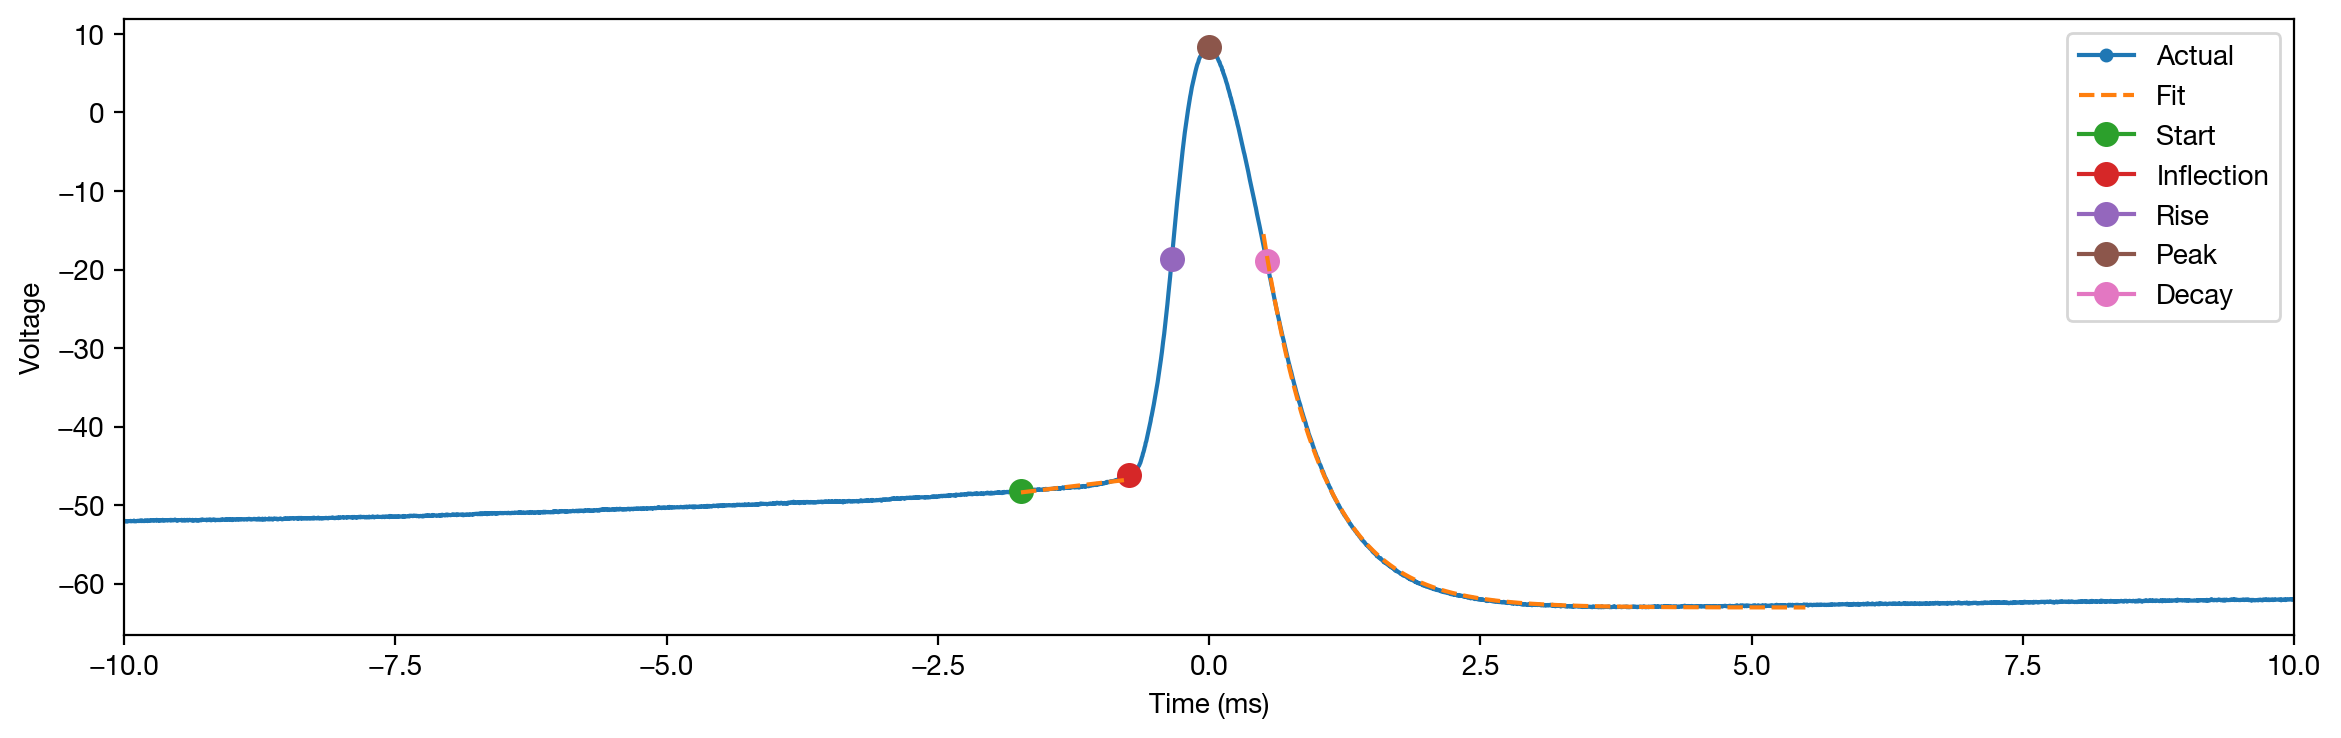

In [2]:
# Same fit as paper_aux_figs/algorithm/AP_empirical_algorithm_sch.ipynb, Part 2 (toy example)
fs = 200000
toy_trace = np.load(DATA_DIR + 'pvc6_c1_toy_trace.npy')

sp_toy = Spike(thresh_amp=-10, window_length=(10, 10), smooth_frac=.01)
sp_toy.fit(toy_trace, fs, n_jobs=1)
sp_toy.plot(show_points=True, inds=0)
plt.show()

### Feature table

Running `spikewise` on every spike from a neuron gives a table where each row is one spike and each column is one feature (Fig. 2C). Below: the first rows for pvc-6 Cell 1, keeping spikes with good ramp and decay fits.

In [3]:
# spikewise features (+ fit R²) for all 820 pvc-6 Cell 1 spikes, precomputed with
# Spike(thresh_amp=-10, window_length=(5., 5.), smooth_frac=.008, pre_inflection_ms=0.5)
df_pvc6 = pd.read_csv(DATA_DIR + 'pvc6_c1_features.csv.gz')

good_pvc6 = df_pvc6.loc[(df_pvc6['r_squared_ramp'] >= 0.5) & (df_pvc6['r_squared_exp'] >= 0.5)]
display_feature_table(good_pvc6, nrows=5)

spike id,ramp amp,inflectiontime,inflectionamp,peakamp,peakwidth,peaksharpness,explambda,expconst,logisi,r2 rampfit,r2 decayfit
0,2.10,0.78,-43.47,9.03,0.94,1.77,1.59,-61.77,2.95,0.95,1.0
1,2.28,0.88,-41.25,8.41,0.98,1.44,1.52,-61.22,2.33,0.97,1.0
2,2.19,0.94,-40.97,7.72,1.00,1.23,1.50,-60.88,2.17,0.96,1.0
3,2.57,0.93,-41.25,8.06,1.01,1.30,1.54,-60.38,3.78,0.98,1.0
4,2.32,0.84,-42.44,9.16,0.95,1.58,1.63,-63.04,2.32,0.94,1.0


## Intra-spike correlations

If these features capture real physiology, they should not vary independently. Correlating every pair of features across all spikes from the same neuron shows that they are systematically intercorrelated (Fig. 2D). In pvc-6 Cell 1 (SST+):
- sharper peaks are narrower;
- spikes with earlier inflection points have wider, less sharp peaks;
- the decay rate (λ) tracks peak shape almost perfectly (r = 0.96 with peak sharpness).

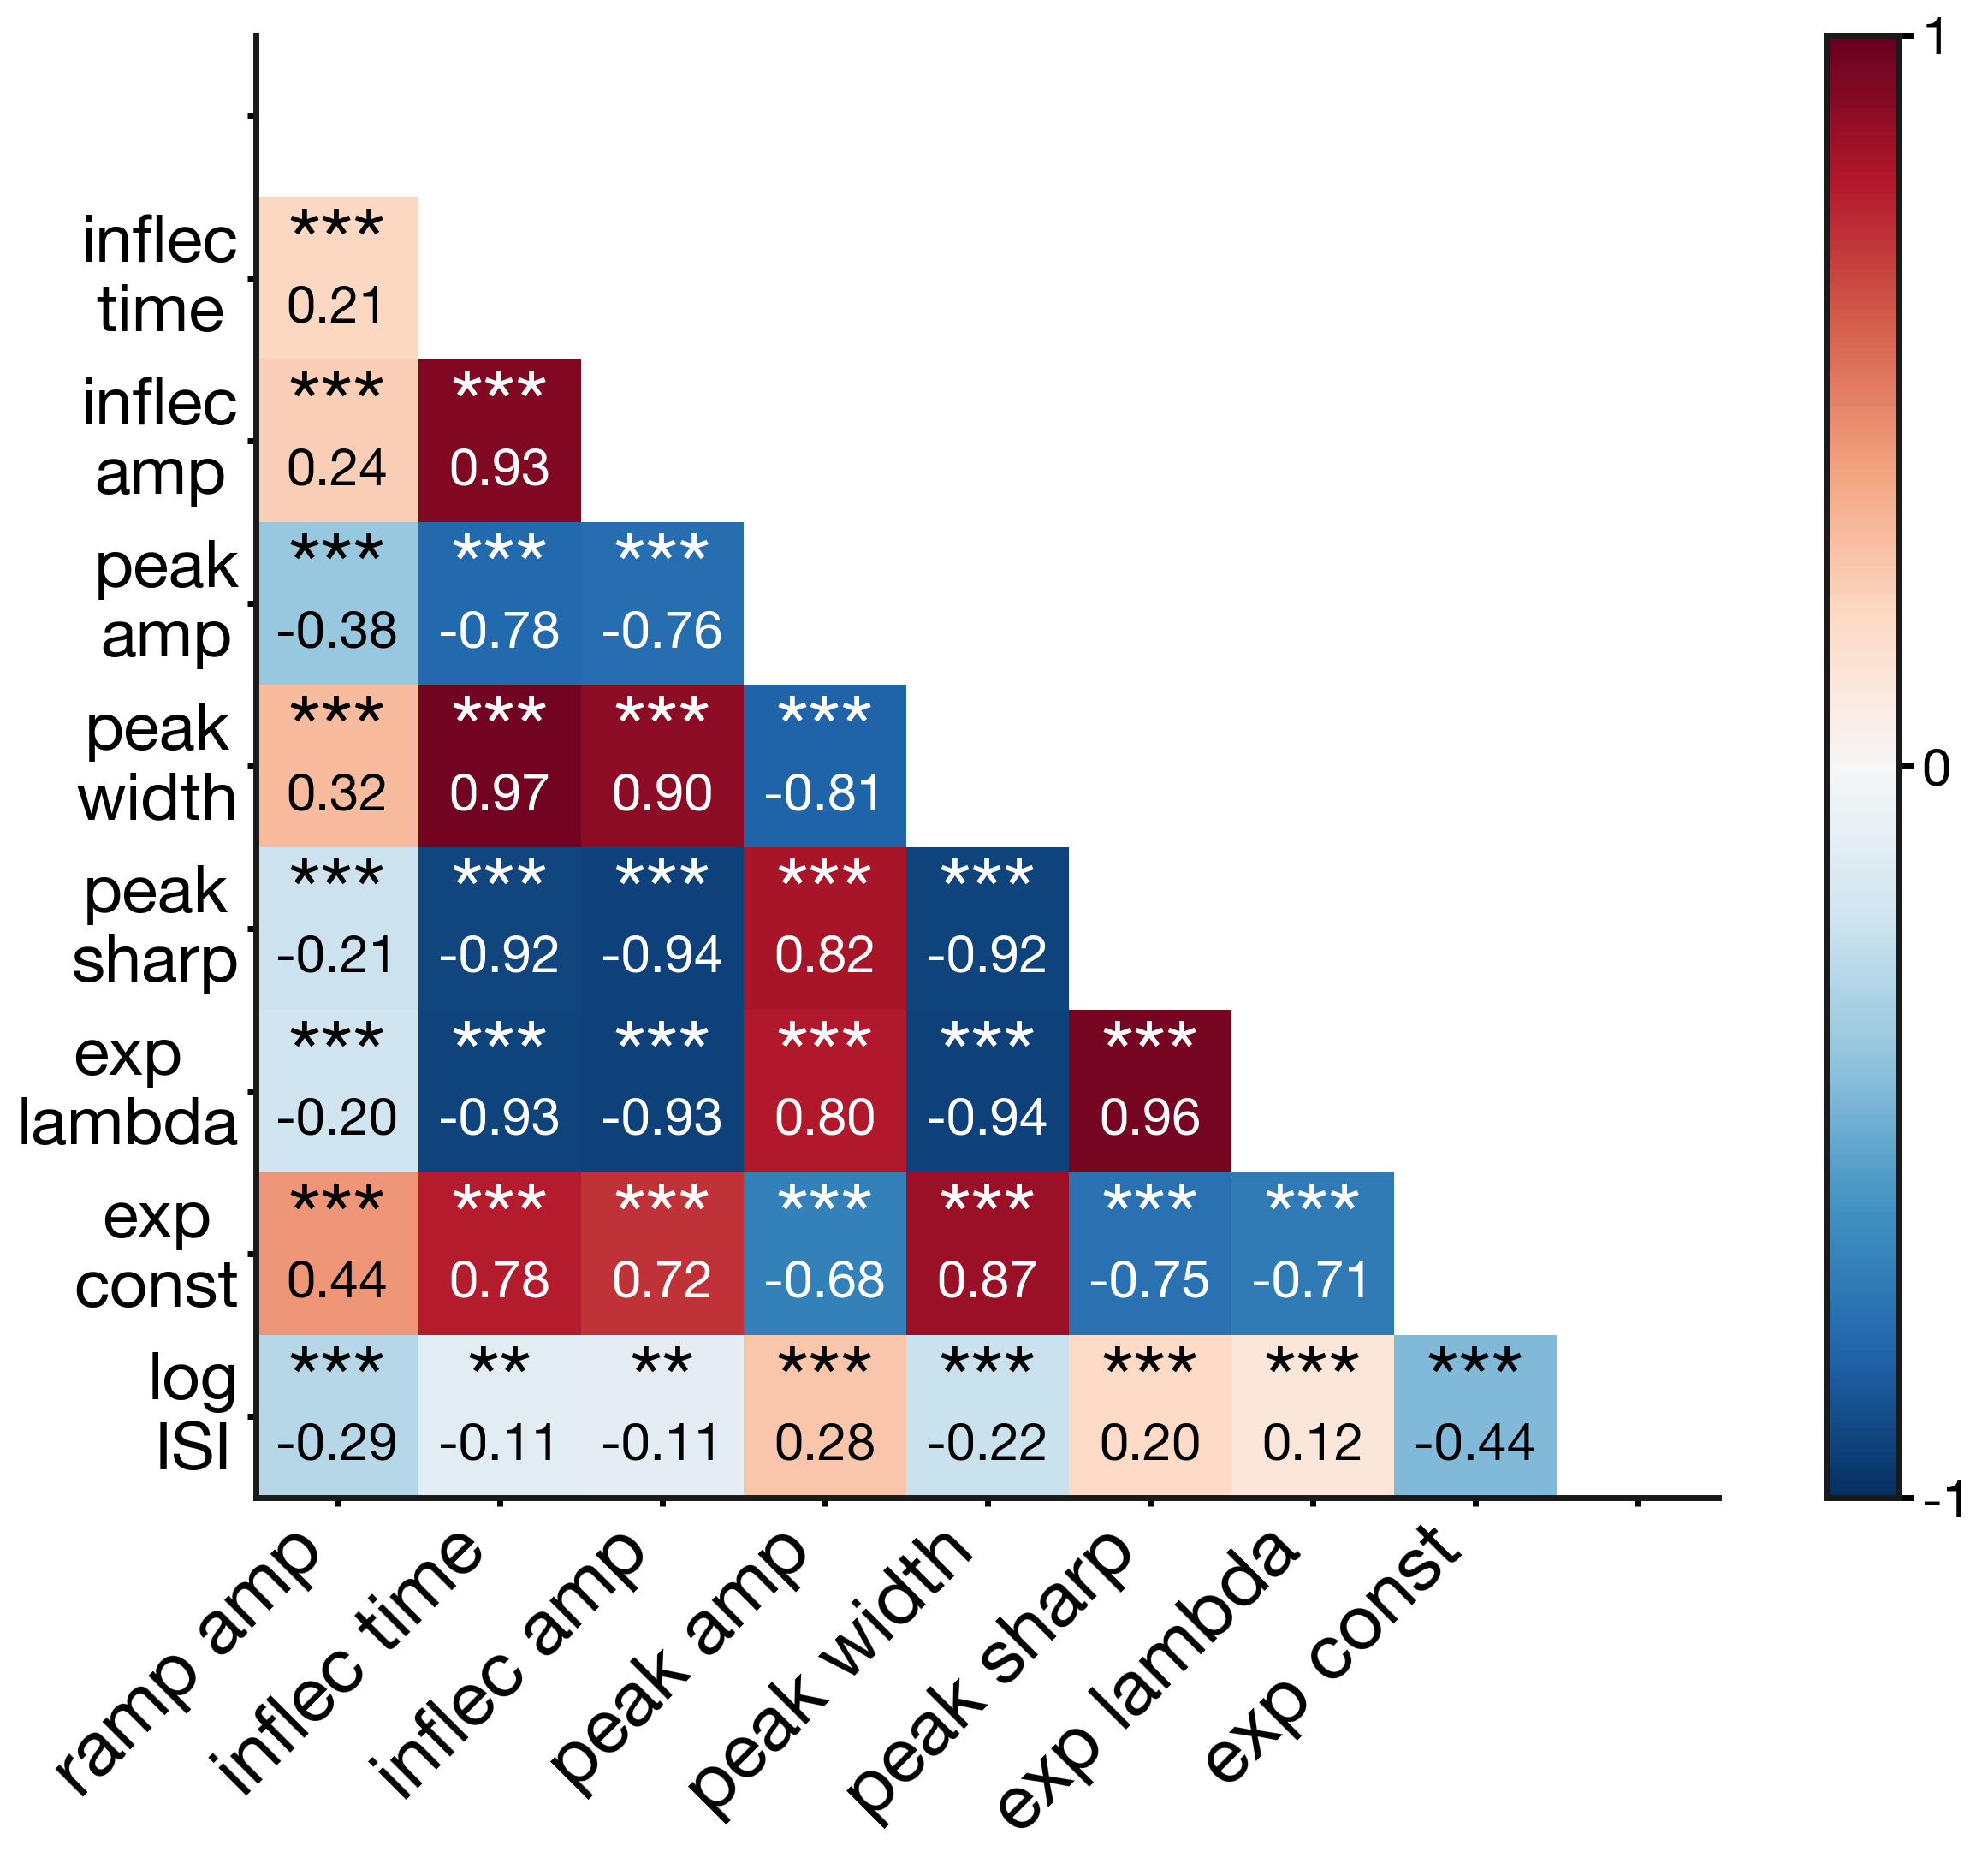

In [4]:
# Same QC and plotting as AP_empirical_algorithm_sch.ipynb (Fig 2D cell)
df_corr = df_pvc6.loc[(df_pvc6['inflection_time'] > 0.) & (df_pvc6['inflection_time'] < 2.)]
df_corr = df_corr.loc[df_corr['r_squared_exp']  >= .5]
df_corr = df_corr.loc[df_corr['r_squared_ramp'] >= .1]

plot_corr_heatmap_only_spk(df_corr, SPK_FEATS)

## Which correlations generalize across cells and datasets?

We looked at two datasets: **pvc-6** (2 neurons from adult mouse visual cortex, in vitro whole-cell patch clamp) and **spe-1** (43 neurons with simultaneous patch clamp and Neuropixels recordings).

Some relationships held in every cell and both datasets: sharper peaks are narrower, and earlier inflection points go with wider, less sharp peaks.

Others vary from cell to cell. The strong decay rate correlations seen in pvc-6 also show up in individual spe-1 cells, but their direction flips between cells: decay rate and peak amplitude were positively correlated in 26 spe-1 cells and negatively in 17. Fit quality does not explain which direction a cell falls in, so this looks like real variability between neurons rather than a fitting artifact. Because of these opposite signs, most decay correlations average out to near zero across the spe-1 population (Supp. Fig. 1).

**Try it:** pick a dataset and a cell from the menus below to plot that cell's correlation matrix.

In [5]:
# Same per-cell features as paper_aux_figs/spe1/supp_intra_spike_correlations.ipynb (Supp Fig 1)
per_cell = pd.read_csv(DATA_DIR + 'per_cell_features.csv.gz')
correlation_matrix_explorer(per_cell, SPK_FEATS)

Output()